# Eredmények Összehasonlítása: Alapmodell vs. HPO

Ez a notebook összeolvassa az alap (`model_comparison_results.csv`) és a hiperparaméter-hangolt (`final_tuned_comparison_results.csv`) futások eredményeit, és vizuálisan elemzi őket generalizáció, HPO hatása, és az adatkiegyensúlyozás (SMOTE vs Class Weight) szempontjából.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

# CSV-k betöltése
base_df = pd.read_csv("ddos-detection/model_comparison/model_comparison_results.csv")
tuned_df = pd.read_csv("ddos-detection/model_comparison_tuned/final_tuned_comparison_results.csv")

base_df["tuning"] = "Base (No HPO)"
tuned_df["tuning"] = "Tuned (HPO)"

# Kombinálás
df = pd.concat([base_df, tuned_df], ignore_index=True)
df.head()

,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec,tuning,best_params
0,boosting,smote_no_class_weight,seta_test,0.962492,0.870528,0.846660,6.922313,1.312933,Base (No HPO),NaN
1,boosting,regular_class_weight,seta_test,0.955035,0.888474,0.836456,2.932996,1.353300,Base (No HPO),NaN
2,random_forest,regular_class_weight,seta_test,0.947132,0.875771,0.832741,5.103329,0.359452,Base (No HPO),NaN
3,random_forest,smote_no_class_weight,seta_test,0.943496,0.895709,0.811456,31.531858,0.447238,Base (No HPO),NaN
4,logistic_regression,smote_no_class_weight,seta_test,0.650775,0.699562,0.391318,21.624688,0.010357,Base (No HPO),NaN


## 1. F1 Macro: SetA (Train/Test) vs SetB (External Generalization)

Itt azt vizsgáljuk, hogyan változik az `f1_macro` a SetA-ról a SetB-re, és hogy a Tuning segített-e a generalizációban.

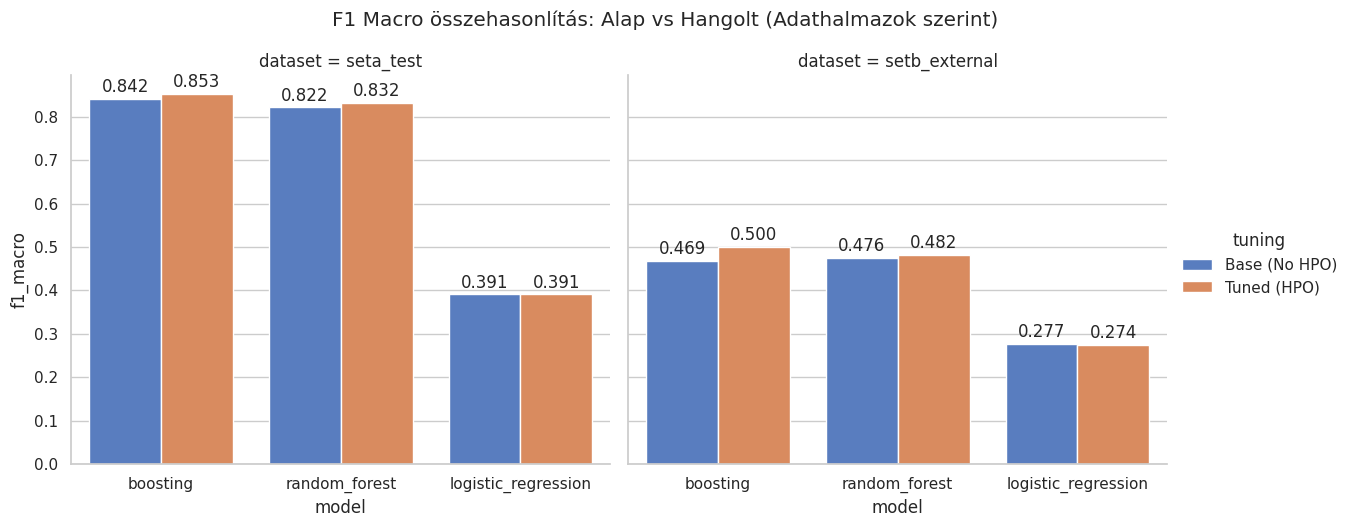

In [16]:
g = sns.catplot(
    data=df,
    x="model", y="f1_macro", hue="tuning", col="dataset",
    kind="bar", errorbar=None, aspect=1.2, height=5, palette="muted"
)

# Értékek megjelenítése az oszlopokon
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2)

plt.suptitle("F1 Macro összehasonlítás: Alap vs Hangolt (Adathalmazok szerint)", y=1.05)
plt.show()

## 2. Generalizációs rés (Overfitting mértéke)

Kiszámoljuk a különbséget a SetA és SetB metrikák között. Minél nagyobb a csökkenés (negatív érték), annál jobban overfit-elt a modell a SetA-ra.

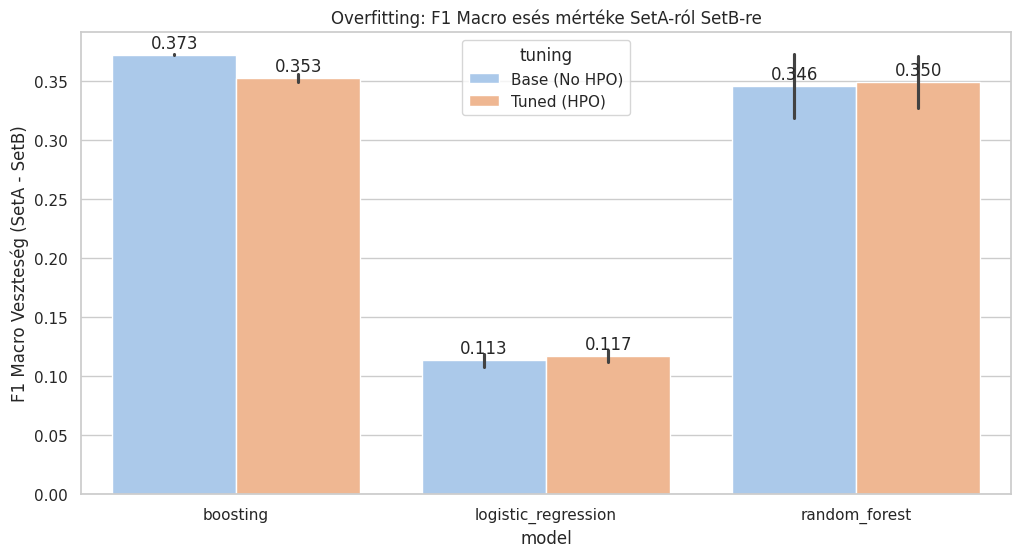

In [17]:
pivot = df.pivot_table(
    index=["model", "scenario", "tuning"],
    columns="dataset",
    values=["f1_macro", "balanced_accuracy"]
).reset_index()

pivot["f1_macro_drop"] = pivot[("f1_macro", "seta_test")] - pivot[("f1_macro", "setb_external")]

# Oszlopnevek kisimítása plotoláshoz
flattened_pivot = pivot.copy()
# Csak azokat a tupléket vonjuk össze, amik eleve tuple-k voltak, az indexeket ne bántsuk
flattened_pivot.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col 
    for col in flattened_pivot.columns.values
]

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=flattened_pivot,
    x="model", y="f1_macro_drop", hue="tuning", 
    palette="pastel"
)

# Értékek megjelenítése az oszlopokon
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2)

plt.title("Overfitting: F1 Macro esés mértéke SetA-ról SetB-re")
plt.ylabel("F1 Macro Veszteség (SetA - SetB)")
plt.show()

## 3. SMOTE vs Regular Class Weight (Tuningolt modelleken)

Megvizsgáljuk, hogy az adatkiegyenlítési módszerek közül melyik bizonyult jobbnak stabilan.

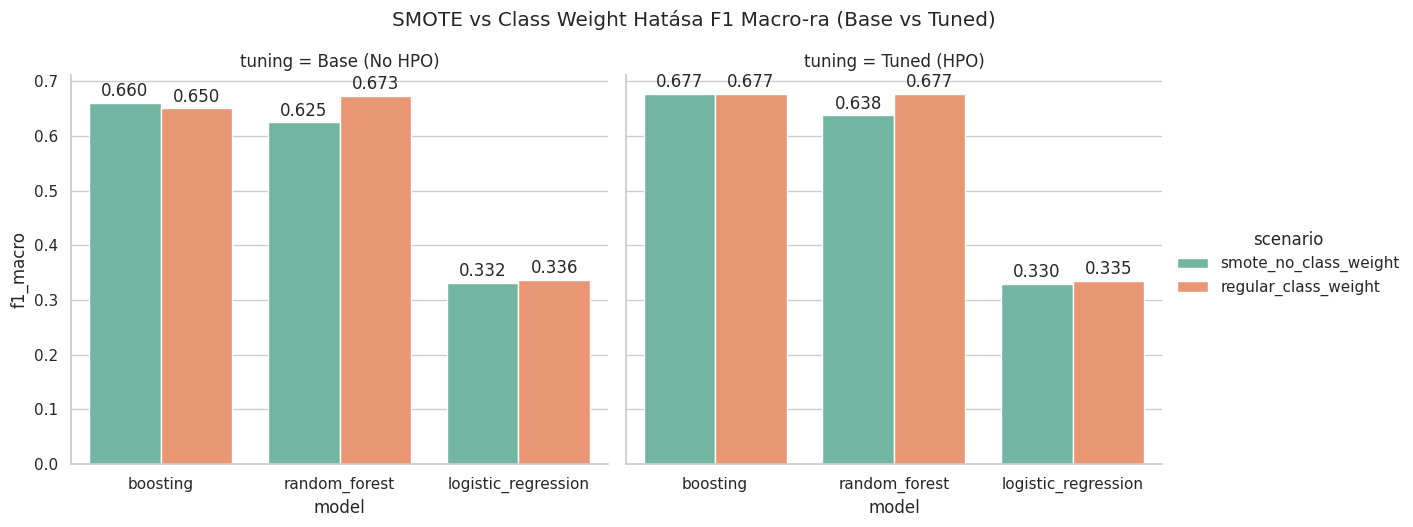

In [18]:
g = sns.catplot(
    data=df,
    x="model", y="f1_macro", hue="scenario", col="tuning",
    kind="bar", errorbar=None, aspect=1.2, height=5, palette="Set2"
)

# Értékek megjelenítése az oszlopokon
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2)

plt.suptitle("SMOTE vs Class Weight Hatása F1 Macro-ra (Base vs Tuned)", y=1.05)
plt.show()